[2026-07-23 14:04:28] [info     ] 开始计算 V1 因子                     end_date='2024-12-31 23:59:59' start_date='2024-01-01 00:00:00'
[2026-07-23 14:04:28] [info     ] 开始构建训练集                        train_end='2023-06-30 23:59:59' train_start='2023-01-01 00:00:00'
[2026-07-23 14:04:28] [info     ] 开始构建特征                         end='2023-06-30 23:59:59' need_label=True query_end='2023-07-10 23:59:59' query_start='2022-11-02 00:00:00' start='2023-01-01 00:00:00'
[2026-07-23 14:04:35] [info     ] 日频行情查询完成                       elapsed=7.27 rows=356973
[2026-07-23 14:04:36] [info     ] 量价特征构造完成                       elapsed=0.35
[2026-07-23 14:04:39] [info     ] 财务数据处理完成                       elapsed=3.11 rows=570272
[2026-07-23 14:04:40] [info     ] 特征构建结束                         dates=118 elapsed=11.69 instruments=1099 rows=117788
[2026-07-23 14:04:40] [info     ] 训练集准备完成                        dates=118 features=16 samples=117787
[2026-07-23 14:04:40] [info     ] 开始训练模型                     

时段,IC
2024-01-15~2024-02-08,-0.0005
2024-09-24~2024-10-08,0.0264

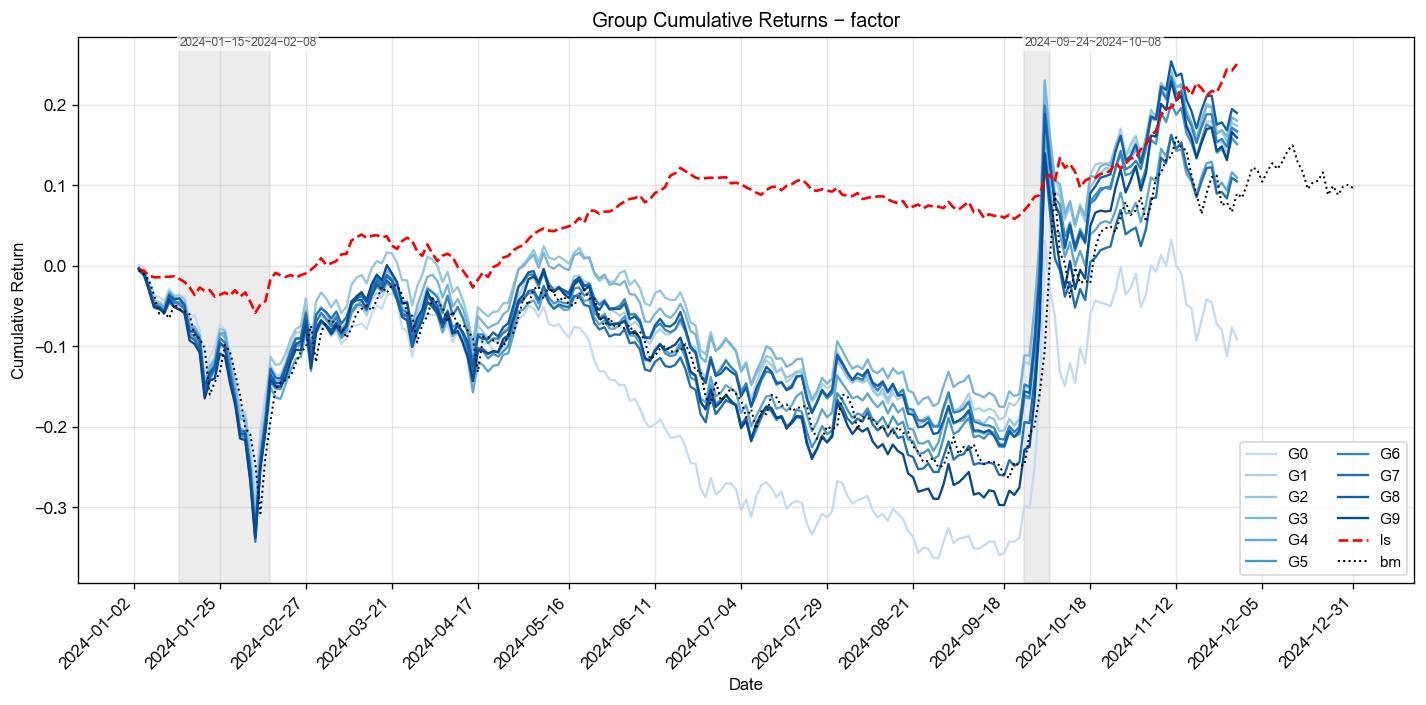
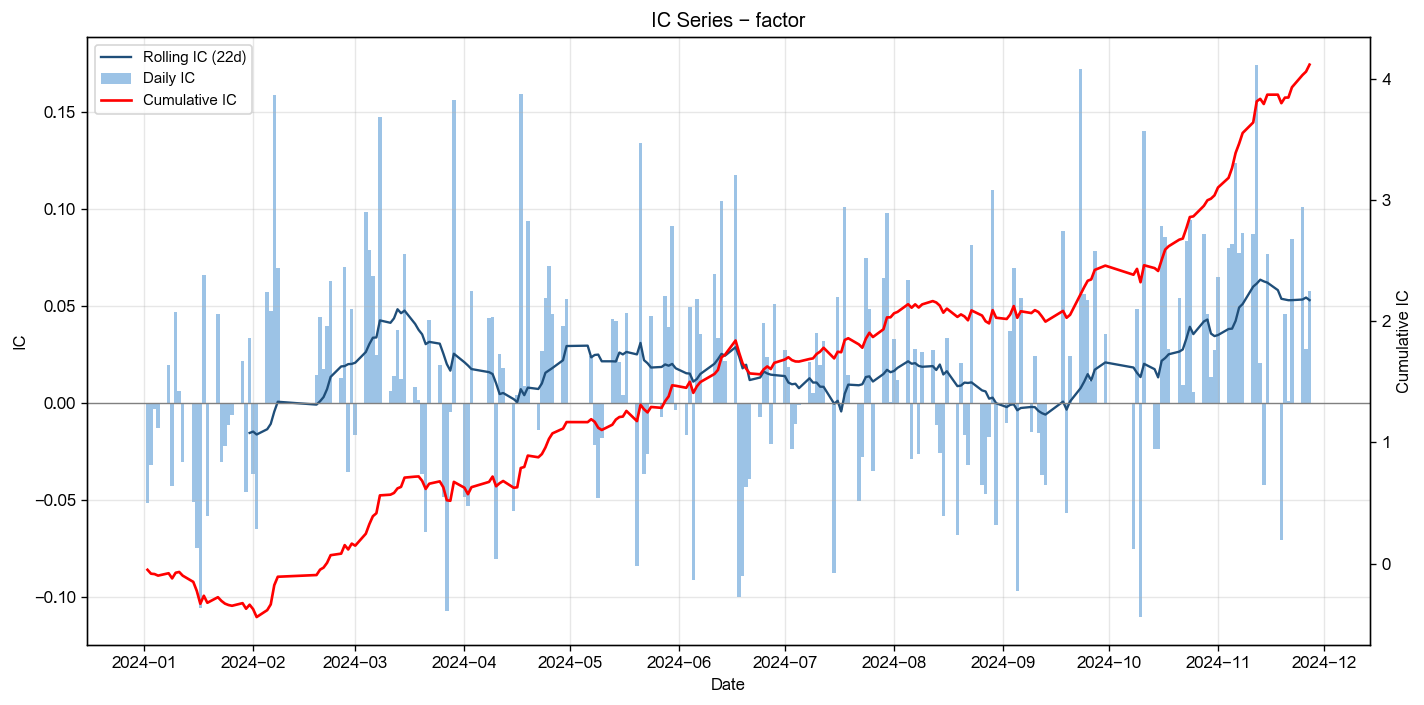
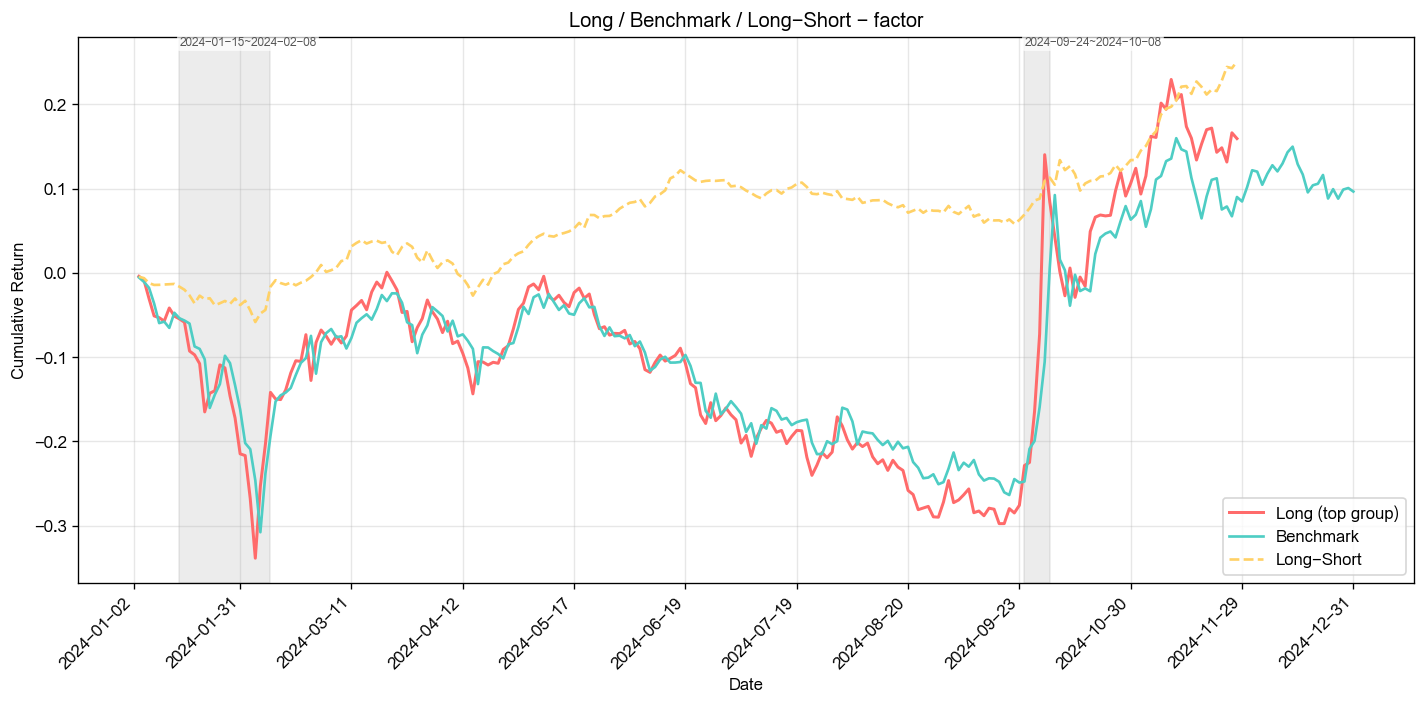
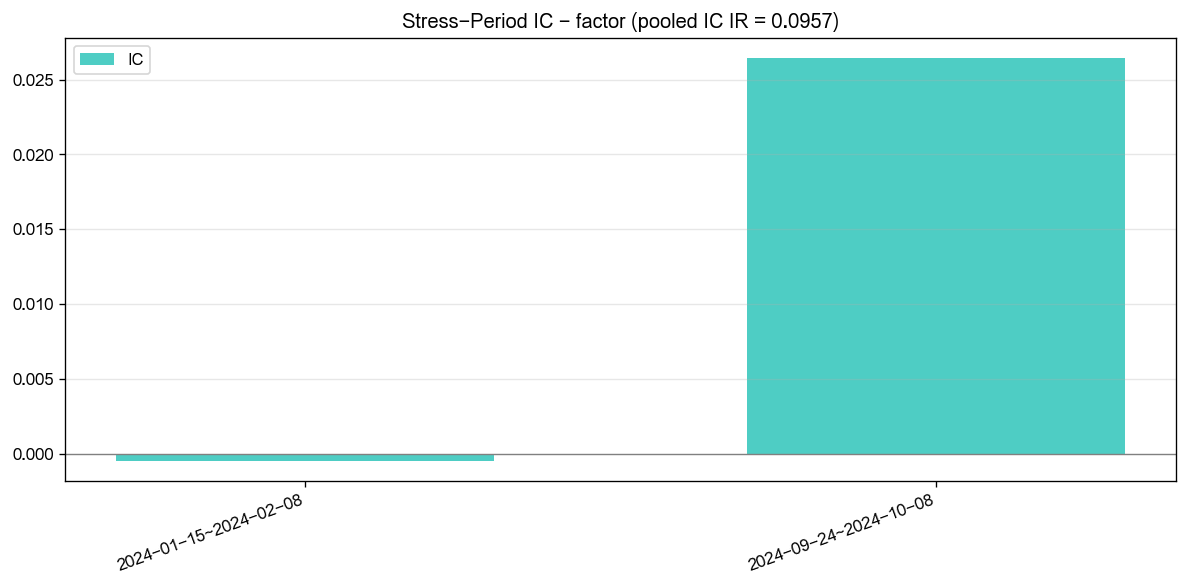
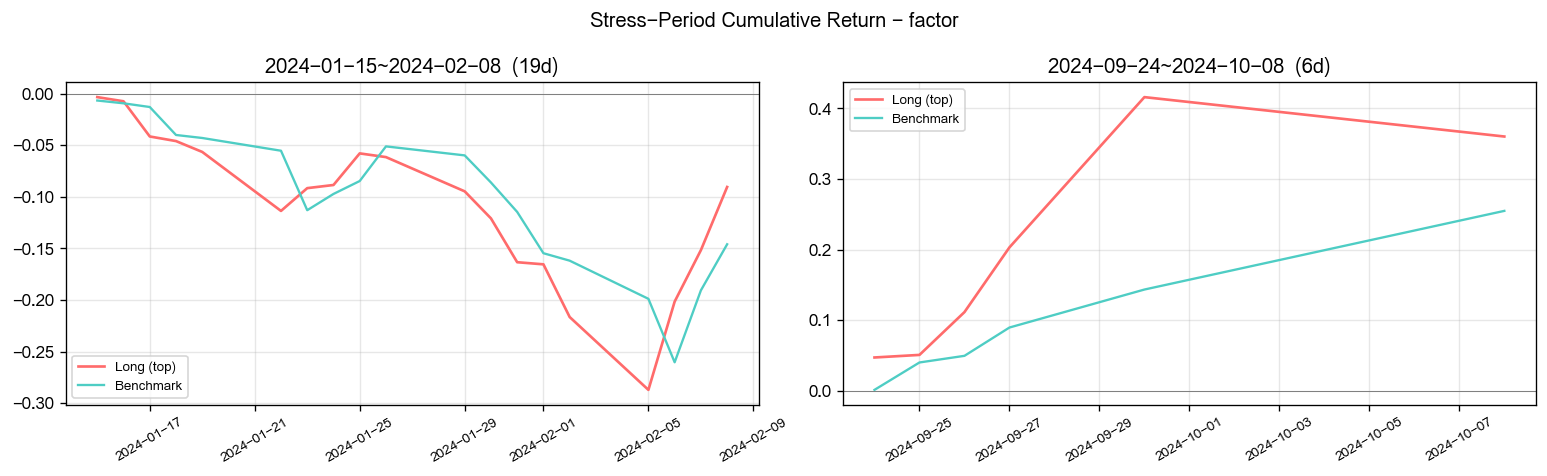

[2026-07-23 14:19:18] [info     ] ========== 因子池回归 ==========
[2026-07-23 14:19:18] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-23 14:19:19] [info     ] 获取收益率数据, 耗时: 0.7017 秒
[2026-07-23 14:19:20] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.2906 秒
[2026-07-23 14:19:20] [info     ] 统计 回归结果, 耗时: 0.0064 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9291,0.0440,0.0228,1.0000
2,factor,1.8328,0.0079,0.0043,1.0000
3,amount,1.7551,0.0185,0.0106,1.0000
4,netflow_amount_main,1.5067,0.0253,0.0168,1.0000
5,net_profit_rate_ttm,1.4734,0.0041,0.0028,0.8000
6,netflow_amount_rate_main,1.4722,0.0096,0.0066,1.0000
7,bias_20,1.4425,0.0290,0.0201,0.9000
8,gross_profit_rate_ttm,1.4381,0.0067,0.0047,1.0000
9,pb,1.4198,0.0097,0.0068,0.9000
10,cci_14,1.4114,0.0342,0.0243,1.0000

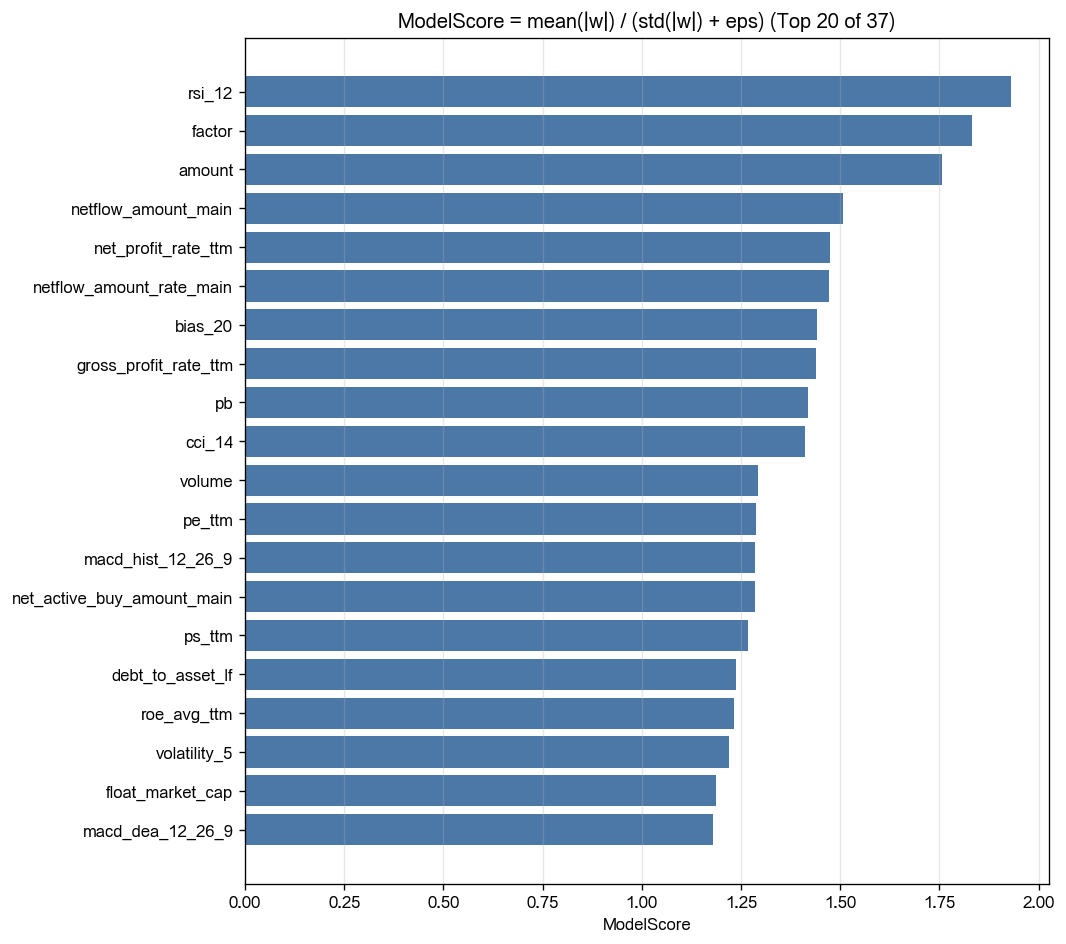
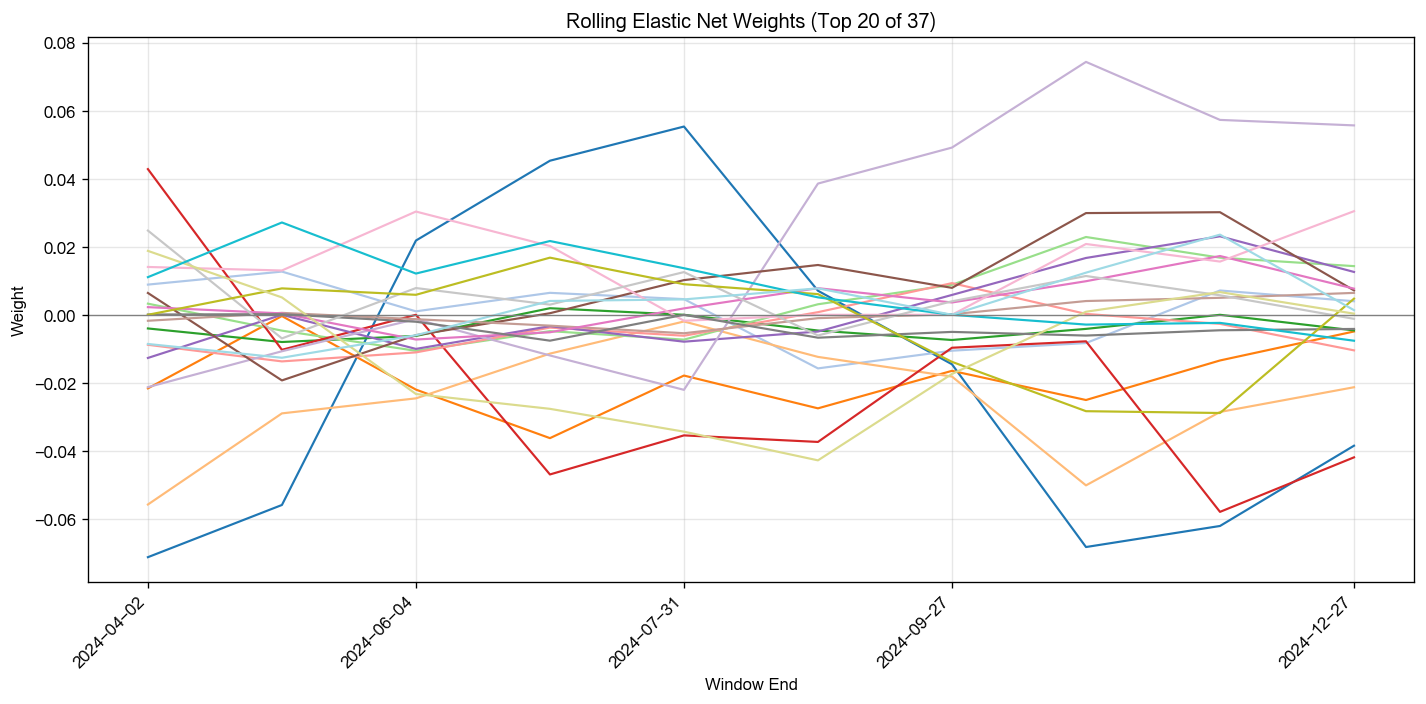
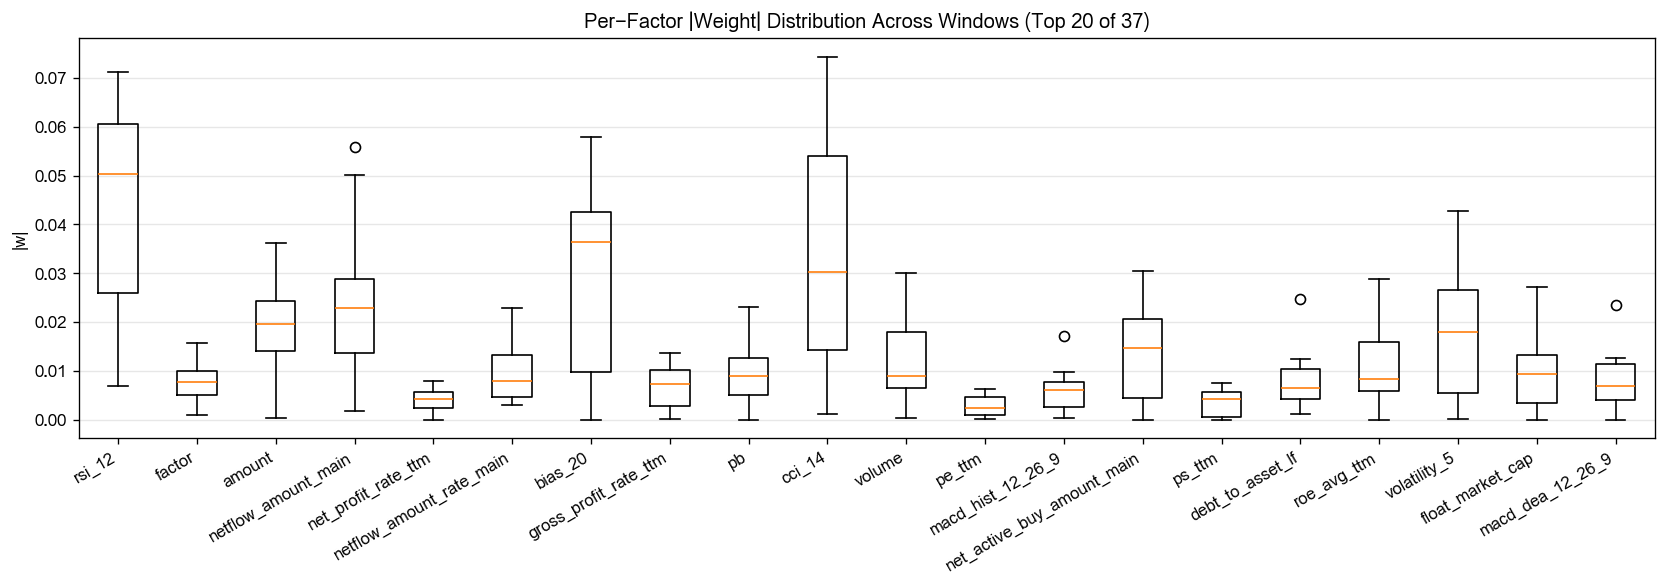
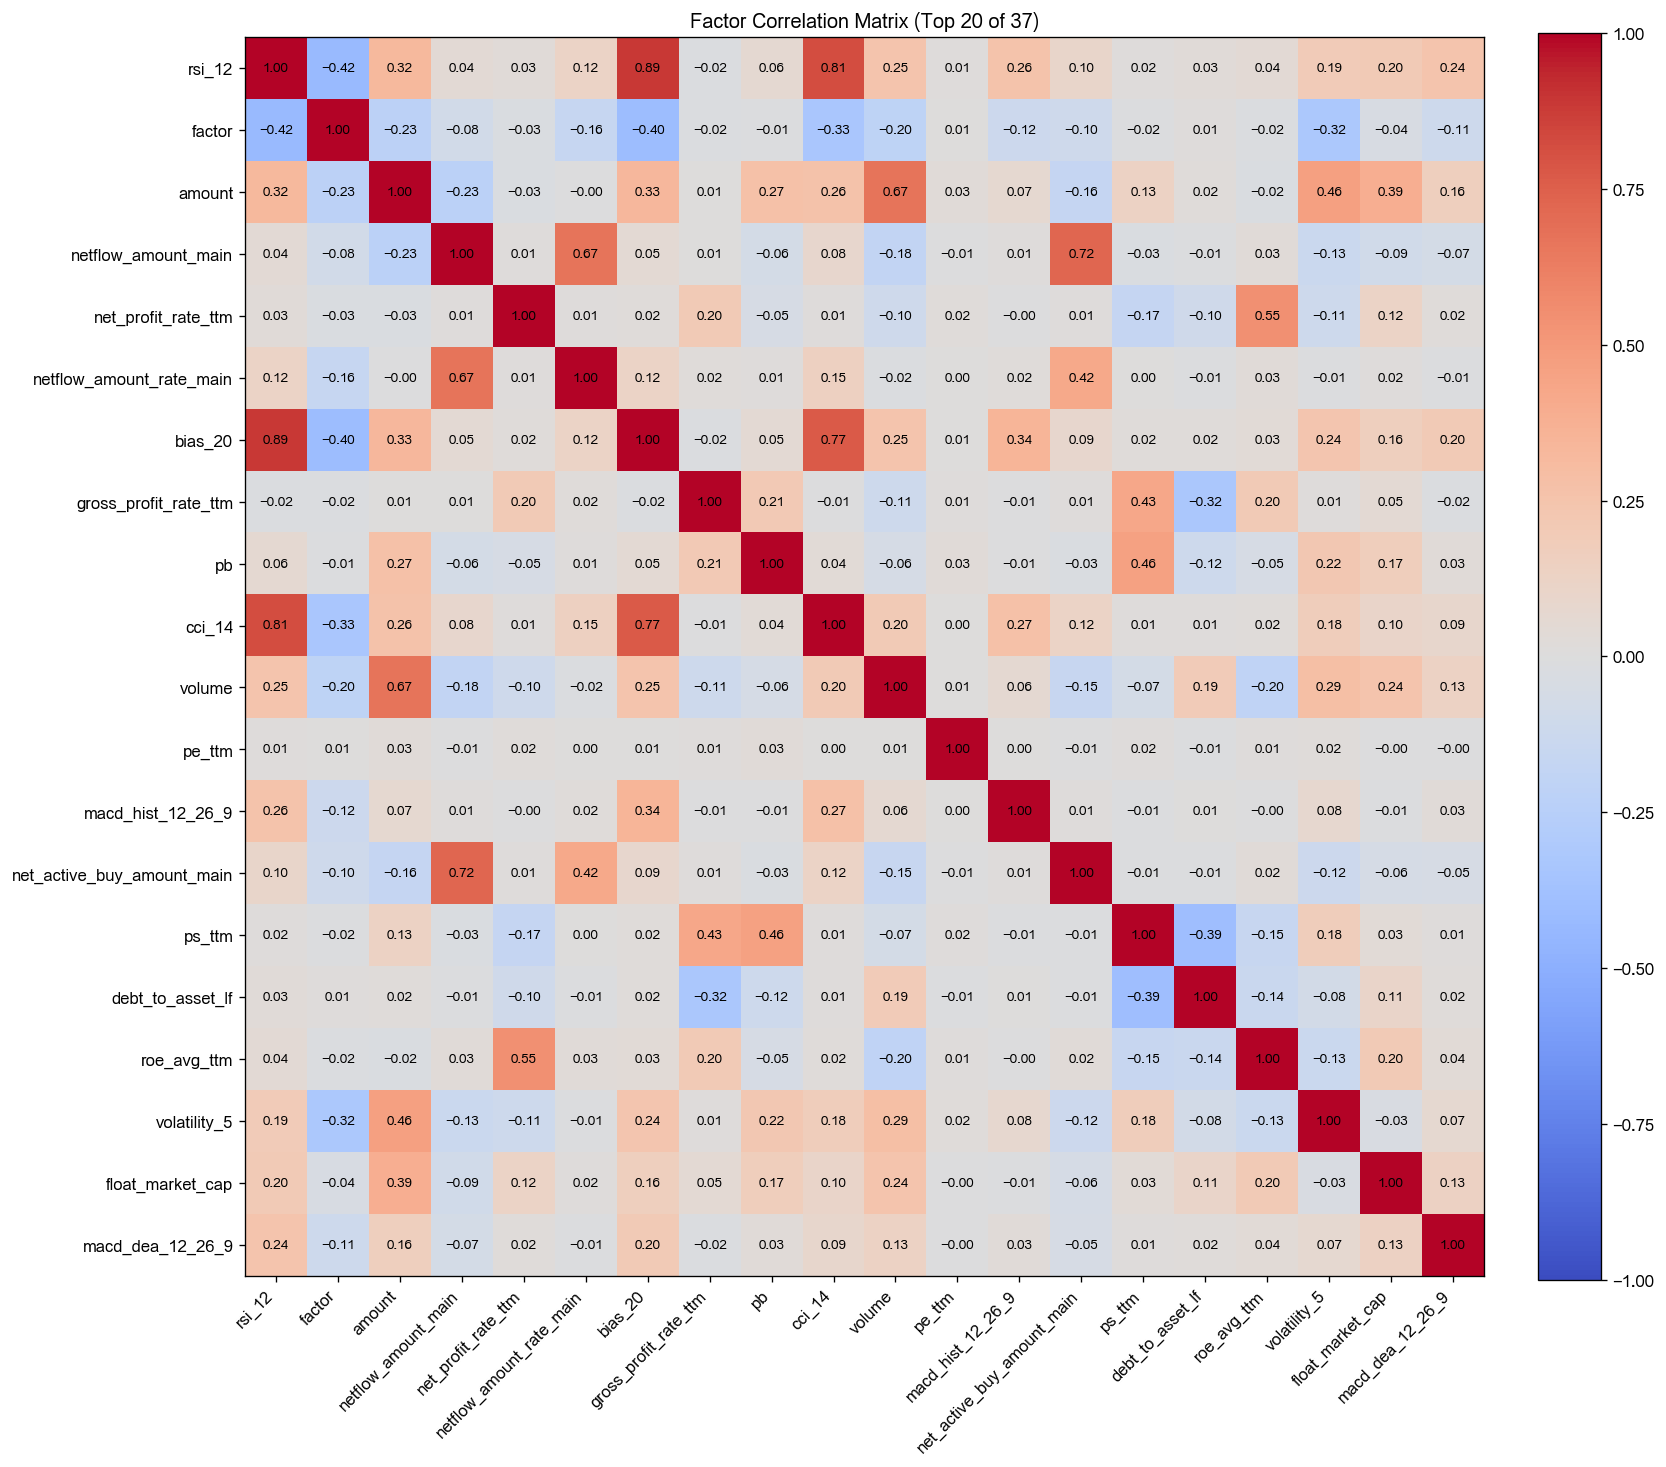

[2026-07-23 14:19:22] [warning  ] 返回的Outputs实例(size=35265551) 大于 64K, 将不会被缓存
[2026-07-23 14:19:22] [info     ] bigalpha_eval.v4 运行完成 [74.254s].
{'raw_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.007581
1      2024-01-02  000012.SZ  0.021397
2      2024-01-02  000016.SZ -0.012743
3      2024-01-02  000019.SZ -0.022752
4      2024-01-02  000025.SZ -0.007847
...           ...        ...       ...
241765 2024-12-31  688766.SH -0.012957
241766 2024-12-31  688776.SH  0.001371
241767 2024-12-31  688779.SH  0.034724
241768 2024-12-31  688789.SH -0.031985
241769 2024-12-31  688798.SH  0.009025

[241770 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.SZ -0.000908
1      2024-01-02  000012.SZ  0.412617
2      2024-01-02  000016.SZ -1.138823
3      2024-01-02  000019.SZ -0.979228
4      2024-01-02  000025.SZ -0.129429
...           ...        ...       ...
241995 2024-12-31  688766.SH -0.464420
241996 2024-12-

In [2]:
def main(datasources, start_date, end_date):
    """
    V1：XGBoost 量价 + 财务质量混合因子

    核心思路：
        1. 使用固定历史区间训练模型；
        2. 从分钟行情聚合日频 OHLCV；
        3. 构造收益、波动率、成交异常等量价特征；
        4. 构造 ROE、ROA、净利率等财务质量特征；
        5. 将特征转换为每日截面百分位排名；
        6. 预测下一交易日股票截面收益排名；
        7. 模型预测值作为最终 factor。

    重要：
        start_date 和 end_date 是平台传入的测试区间，
        不能使用该区间训练模型。

    返回：
        pd.DataFrame，包含：
        ['date', 'instrument', 'factor']
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 1. 固定训练区间
    # ============================================================
    # 当前默认假设正式测试区间位于 2024 年。
    # 训练区间必须早于测试区间，不能使用平台传入日期训练。
    TRAIN_START = '2022-01-01 00:00:00'
    TRAIN_END = '2023-12-31 23:59:59'

    # 滚动特征最长为 20 个交易日。
    # 向前读取 60 个自然日，一般能够覆盖足够的交易日。
    LOOKBACK_DAYS = 60

    # 为训练区间最后一天构造 next_ret，需要多读取未来若干自然日。
    LABEL_FORWARD_DAYS = 10

    # ============================================================
    # 2. 原始字段与模型特征
    # ============================================================
    financial_raw_cols = [
        'operating_revenue',
        'net_profit_to_parent_shareholders',
        'total_assets',
        'total_equity_to_parent_shareholders',
    ]

    # 先构造这些经济含义明确的特征。
    base_feature_cols = [
        # 收益与价格结构
        'ret_1d',
        'ret_5d',
        'ret_20d',
        'intraday_ret',
        'overnight_ret',
        'high_low_range',
        'close_position',

        # 波动率
        'volatility_5d',
        'volatility_20d',

        # 量能异常
        'volume_ratio_20d',
        'amount_ratio_20d',

        # 财务质量
        'roe_proxy',
        'roa_proxy',
        'net_margin',
        'equity_asset_ratio',
        'asset_log',
    ]

    # 最终输入模型的是每日截面排名特征。
    feature_cols = [
        f'{col}_rank'
        for col in base_feature_cols
    ]

    # ============================================================
    # 3. 辅助函数：安全除法
    # ============================================================
    def safe_divide(numerator, denominator):
        """
        安全除法：
        - 分母过小时返回 NaN；
        - 自动处理 inf。
        """
        denominator = denominator.where(
            denominator.abs() > 1e-12,
            np.nan
        )

        result = numerator / denominator

        return result.replace(
            [np.inf, -np.inf],
            np.nan
        )

    # ============================================================
    # 4. 辅助函数：财务公告日数据扩展到自然日
    # ============================================================
    def fill_financial_to_natural_dates(fin, natural_start, natural_end):
        """
        按股票将财务公告日数据向后填充到自然日。

        PIT 原则：
        某份财务数据只能从公告日开始使用，
        不能向公告日之前填充。
        """
        if fin.empty:
            return fin

        fin = fin.copy()
        fin['date'] = pd.to_datetime(fin['date'])
        fin['instrument'] = fin['instrument'].astype(str)

        # 避免同一股票、同一日期出现重复财务记录。
        fin = (
            fin.sort_values(['instrument', 'date'])
            .drop_duplicates(
                subset=['date', 'instrument'],
                keep='last'
            )
        )

        natural_dates = pd.date_range(
            start=pd.to_datetime(natural_start).normalize(),
            end=pd.to_datetime(natural_end).normalize(),
            freq='D'
        )

        filled_groups = []

        for instrument, group in fin.groupby(
            'instrument',
            sort=False
        ):
            group = (
                group.sort_values('date')
                .set_index('date')
            )

            # 同一天只保留最后一条记录。
            group = group[
                ~group.index.duplicated(keep='last')
            ]

            expanded = group.reindex(natural_dates)

            # 只能向未来填充，不能向过去填充。
            expanded[financial_raw_cols] = (
                expanded[financial_raw_cols].ffill()
            )

            expanded['instrument'] = instrument
            expanded.index.name = 'date'

            filled_groups.append(
                expanded.reset_index()
            )

        if not filled_groups:
            return pd.DataFrame(
                columns=[
                    'date',
                    'instrument',
                    *financial_raw_cols
                ]
            )

        result = pd.concat(
            filled_groups,
            ignore_index=True
        )

        return result[
            [
                'date',
                'instrument',
                *financial_raw_cols
            ]
        ]

    # ============================================================
    # 5. 特征构建函数
    # ============================================================
    def build_features(
        financial_table,
        bar1m_table,
        sd,
        ed,
        need_label
    ):
        """
        为任意区间构造日频特征。

        need_label=True：
            训练集，构造下一交易日收益排名标签。

        need_label=False：
            测试集，只构造特征，不依赖未来标签。
        """
        total_start_time = time.time()

        sd_ts = pd.to_datetime(sd)
        ed_ts = pd.to_datetime(ed)

        # 为滚动特征向前读取数据。
        query_start = (
            sd_ts - pd.Timedelta(days=LOOKBACK_DAYS)
        )

        # 训练集需要额外读取未来几天，生成最后几日标签。
        if need_label:
            query_end = (
                ed_ts +
                pd.Timedelta(days=LABEL_FORWARD_DAYS)
            )
        else:
            query_end = ed_ts

        logger.info(
            "开始构建特征",
            start=str(sd_ts),
            end=str(ed_ts),
            query_start=str(query_start),
            query_end=str(query_end),
            need_label=need_label
        )

        # ========================================================
        # 5.1 查询分钟行情并聚合到日频
        # ========================================================
        price_start_time = time.time()

        price_sql = f"""
        SELECT
            date_trunc('day', date)::DATE AS trading_day,
            instrument,
            ARG_MIN(open, date)           AS open,
            MAX(high)                     AS high,
            MIN(low)                      AS low,
            ARG_MAX(close, date)          AS close,
            SUM(volume)                   AS volume,
            SUM(amount)                   AS amount
        FROM {bar1m_table}
        GROUP BY trading_day, instrument
        ORDER BY trading_day, instrument
        """

        price = dai.query(
            price_sql,
            filters={
                'date': [
                    query_start,
                    query_end
                ]
            }
        ).df()

        price = price.rename(
            columns={'trading_day': 'date'}
        )

        price['date'] = pd.to_datetime(price['date'])
        price['instrument'] = (
            price['instrument'].astype(str)
        )

        raw_price_cols = [
            'open',
            'high',
            'low',
            'close',
            'volume',
            'amount'
        ]

        # DuckDB 的 SUM 可能生成 Decimal/object，
        # XGBoost 和部分 Pandas 运算无法直接处理。
        for col in raw_price_cols:
            price[col] = pd.to_numeric(
                price[col],
                errors='coerce'
            )

            price[col] = price[col].replace(
                [np.inf, -np.inf],
                np.nan
            )

        price = (
            price.sort_values(
                ['instrument', 'date']
            )
            .drop_duplicates(
                subset=['date', 'instrument'],
                keep='last'
            )
            .reset_index(drop=True)
        )

        logger.info(
            "日频行情查询完成",
            rows=len(price),
            elapsed=round(
                time.time() - price_start_time,
                2
            )
        )

        if price.empty:
            logger.warning("行情数据为空")

            return pd.DataFrame(
                columns=[
                    'date',
                    'instrument',
                    *feature_cols,
                    'label',
                    'next_ret'
                ]
            )

        # ========================================================
        # 5.2 构造未来收益标签的原始值
        # ========================================================
        # 这里必须在过滤股票池前计算。
        # 否则股票退出成分股后再进入，可能误把较远日期视为下一日。
        close_group = price.groupby(
            'instrument',
            sort=False
        )['close']

        next_close = close_group.shift(-1)

        price['next_ret'] = safe_divide(
            next_close,
            price['close']
        ) - 1

        # ========================================================
        # 5.3 构造量价特征
        # ========================================================
        feature_start_time = time.time()

        grouped = price.groupby(
            'instrument',
            sort=False,
            group_keys=False
        )

        previous_close = grouped['close'].shift(1)
        close_5d_ago = grouped['close'].shift(5)
        close_20d_ago = grouped['close'].shift(20)

        # 1 日收益
        price['ret_1d'] = (
            safe_divide(
                price['close'],
                previous_close
            ) - 1
        )

        # 5 日收益
        price['ret_5d'] = (
            safe_divide(
                price['close'],
                close_5d_ago
            ) - 1
        )

        # 20 日收益
        price['ret_20d'] = (
            safe_divide(
                price['close'],
                close_20d_ago
            ) - 1
        )

        # 当日开盘至收盘收益
        price['intraday_ret'] = (
            safe_divide(
                price['close'],
                price['open']
            ) - 1
        )

        # 前收盘至当日开盘的隔夜收益
        price['overnight_ret'] = (
            safe_divide(
                price['open'],
                previous_close
            ) - 1
        )

        # 当日最高价与最低价的相对振幅
        price['high_low_range'] = (
            safe_divide(
                price['high'],
                price['low']
            ) - 1
        )

        # 收盘价在当日价格区间中的位置：
        # 接近 1 表示收盘接近日内最高价；
        # 接近 0 表示收盘接近日内最低价。
        price['close_position'] = safe_divide(
            price['close'] - price['low'],
            price['high'] - price['low']
        )

        # 按股票重新分组，以使用新生成的 ret_1d。
        ret_group = price.groupby(
            'instrument',
            sort=False
        )['ret_1d']

        # 5 日收益波动率
        price['volatility_5d'] = (
            ret_group
            .rolling(
                window=5,
                min_periods=3
            )
            .std()
            .reset_index(
                level=0,
                drop=True
            )
        )

        # 20 日收益波动率
        price['volatility_20d'] = (
            ret_group
            .rolling(
                window=20,
                min_periods=10
            )
            .std()
            .reset_index(
                level=0,
                drop=True
            )
        )

        # 过去 20 日平均成交量
        volume_mean_20d = (
            price.groupby(
                'instrument',
                sort=False
            )['volume']
            .rolling(
                window=20,
                min_periods=5
            )
            .mean()
            .reset_index(
                level=0,
                drop=True
            )
        )

        # 当日成交量相对过去 20 日平均水平
        price['volume_ratio_20d'] = safe_divide(
            price['volume'],
            volume_mean_20d
        )

        # 过去 20 日平均成交额
        amount_mean_20d = (
            price.groupby(
                'instrument',
                sort=False
            )['amount']
            .rolling(
                window=20,
                min_periods=5
            )
            .mean()
            .reset_index(
                level=0,
                drop=True
            )
        )

        # 当日成交额相对过去 20 日平均水平
        price['amount_ratio_20d'] = safe_divide(
            price['amount'],
            amount_mean_20d
        )

        logger.info(
            "量价特征构造完成",
            elapsed=round(
                time.time() - feature_start_time,
                2
            )
        )

        # ========================================================
        # 5.4 查询 PIT 财务数据
        # ========================================================
        financial_start_time = time.time()

        # 多读取一年，以保证查询起点可以找到最近一次公告。
        financial_query_start = (
            query_start -
            pd.Timedelta(days=365)
        )

        fin_select = ', '.join(
            financial_raw_cols
        )

        financial_sql = f"""
        SELECT
            date,
            instrument,
            {fin_select}
        FROM {financial_table}
        WHERE category = 'lf'
          AND shift = 0
        """

        fin = dai.query(
            financial_sql,
            filters={
                'date': [
                    financial_query_start,
                    query_end
                ]
            }
        ).df()

        if not fin.empty:
            fin['date'] = pd.to_datetime(fin['date'])
            fin['instrument'] = (
                fin['instrument'].astype(str)
            )

            for col in financial_raw_cols:
                fin[col] = pd.to_numeric(
                    fin[col],
                    errors='coerce'
                )

                fin[col] = fin[col].replace(
                    [np.inf, -np.inf],
                    np.nan
                )

            fin = fill_financial_to_natural_dates(
                fin=fin,
                natural_start=query_start,
                natural_end=query_end
            )

        logger.info(
            "财务数据处理完成",
            rows=len(fin),
            elapsed=round(
                time.time() - financial_start_time,
                2
            )
        )

        # ========================================================
        # 5.5 合并量价和财务数据
        # ========================================================
        # 使用 left join：
        # 即使某只股票财务数据缺失，也保留量价样本。
        if fin.empty:
            df = price.copy()

            for col in financial_raw_cols:
                df[col] = np.nan
        else:
            df = pd.merge(
                price,
                fin,
                how='left',
                on=['date', 'instrument'],
                validate='many_to_one'
            )

        # ========================================================
        # 5.6 构造财务比例特征
        # ========================================================
        # ROE 近似：
        # 归母净利润 / 归母净资产
        df['roe_proxy'] = safe_divide(
            df['net_profit_to_parent_shareholders'],
            df[
                'total_equity_to_parent_shareholders'
            ].abs()
        )

        # ROA 近似：
        # 归母净利润 / 总资产
        df['roa_proxy'] = safe_divide(
            df['net_profit_to_parent_shareholders'],
            df['total_assets'].abs()
        )

        # 净利率：
        # 归母净利润 / 营业收入
        df['net_margin'] = safe_divide(
            df['net_profit_to_parent_shareholders'],
            df['operating_revenue'].abs()
        )

        # 权益资产比：
        # 归母净资产 / 总资产
        df['equity_asset_ratio'] = safe_divide(
            df[
                'total_equity_to_parent_shareholders'
            ],
            df['total_assets'].abs()
        )

        # 总资产取对数，减少绝对规模差异。
        df['asset_log'] = np.log1p(
            df['total_assets'].clip(lower=0)
        )

        # 对明显不合理的财务比率进行宽松裁剪。
        # 裁剪主要用于提高模型稳定性，并非使用未来数据。
        for col in [
            'roe_proxy',
            'roa_proxy',
            'net_margin',
            'equity_asset_ratio'
        ]:
            df[col] = df[col].clip(
                lower=-10,
                upper=10
            )

        # 成交异常度也做宽松裁剪。
        for col in [
            'volume_ratio_20d',
            'amount_ratio_20d'
        ]:
            df[col] = df[col].clip(
                lower=0,
                upper=20
            )

        # ========================================================
        # 5.7 对齐历史中证 1000 成分股
        # ========================================================
        pool = dai.query(
            """
            SELECT date, instrument
            FROM bigalpha_2026_instruments
            """,
            filters={
                'date': [
                    query_start,
                    query_end
                ]
            }
        ).df()

        pool['date'] = pd.to_datetime(pool['date'])
        pool['instrument'] = (
            pool['instrument'].astype(str)
        )

        pool = pool.drop_duplicates(
            subset=['date', 'instrument']
        )

        # 只有对齐股票池后，才能进行正确的每日截面排名。
        df = pd.merge(
            df,
            pool,
            how='inner',
            on=['date', 'instrument']
        )

        # ========================================================
        # 5.8 清理特征异常值
        # ========================================================
        for col in base_feature_cols:
            df[col] = pd.to_numeric(
                df[col],
                errors='coerce'
            )

            df[col] = df[col].replace(
                [np.inf, -np.inf],
                np.nan
            )

        # ========================================================
        # 5.9 每日截面百分位排名
        # ========================================================
        # 例如 ret_5d_rank=0.9：
        # 表示该股票五日收益位于当日股票池前约 10%。
        for col in base_feature_cols:
            rank_col = f'{col}_rank'

            df[rank_col] = (
                df.groupby(
                    'date',
                    sort=False
                )[col]
                .rank(
                    method='average',
                    pct=True
                )
            )

            # 将 [0, 1] 居中到 [-0.5, 0.5]。
            df[rank_col] = (
                df[rank_col] - 0.5
            )

        # ========================================================
        # 5.10 构造下一日截面收益排名标签
        # ========================================================
        if need_label:
            df['label'] = (
                df.groupby(
                    'date',
                    sort=False
                )['next_ret']
                .rank(
                    method='average',
                    pct=True
                )
            )

            # 标签居中到 [-0.5, 0.5]。
            df['label'] = (
                df['label'] - 0.5
            )
        else:
            df['label'] = np.nan

        # ========================================================
        # 5.11 只返回目标日期范围
        # ========================================================
        df = df[
            (df['date'] >= sd_ts) &
            (df['date'] <= ed_ts)
        ].copy()

        # 防止重复行。
        df = (
            df.sort_values(
                ['date', 'instrument']
            )
            .drop_duplicates(
                subset=['date', 'instrument'],
                keep='last'
            )
            .reset_index(drop=True)
        )

        logger.info(
            "特征构建结束",
            rows=len(df),
            dates=int(df['date'].nunique()),
            instruments=int(
                df['instrument'].nunique()
            ),
            elapsed=round(
                time.time() - total_start_time,
                2
            )
        )

        return df

    # ============================================================
    # 6. 构建训练集
    # ============================================================
    logger.info(
        "开始构建训练集",
        train_start=TRAIN_START,
        train_end=TRAIN_END
    )

    train_df = build_features(
        financial_table='bigalpha_2026_financial',
        bar1m_table='bigalpha_2026_stock_bar1m',
        sd=TRAIN_START,
        ed=TRAIN_END,
        need_label=True
    )

    train_df['label'] = train_df['label'].replace(
        [np.inf, -np.inf],
        np.nan
    )

    # 删除没有未来收益标签的行。
    train_df = train_df.dropna(
        subset=['label']
    )

    # 删除所有模型特征均为空的样本。
    train_df = train_df.dropna(
        subset=feature_cols,
        how='all'
    )

    if train_df.empty:
        raise ValueError(
            "训练集为空，请检查训练日期、数据表和特征构造逻辑。"
        )

    logger.info(
        "训练集准备完成",
        samples=len(train_df),
        dates=int(train_df['date'].nunique()),
        features=len(feature_cols)
    )

    # ============================================================
    # 7. 训练 XGBoost 模型
    # ============================================================
    fit_start_time = time.time()

    model = xgb.XGBRegressor(
        objective='reg:squarederror',

        # 模型容量
        n_estimators=150,
        max_depth=4,
        learning_rate=0.03,

        # 降低过拟合
        min_child_weight=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=5.0,

        # 加速
        tree_method='hist',
        n_jobs=-1,

        # 可复现
        random_state=42
    )

    logger.info(
        "开始训练模型",
        samples=len(train_df),
        features=len(feature_cols)
    )

    model.fit(
        train_df[feature_cols],
        train_df['label']
    )

    logger.info(
        "模型训练完成",
        elapsed=round(
            time.time() - fit_start_time,
            2
        )
    )

    # 输出特征重要性，便于本地分析。
    feature_importance = (
        pd.Series(
            model.feature_importances_,
            index=feature_cols
        )
        .sort_values(ascending=False)
    )

    logger.info(
        "模型特征重要性",
        top_features=feature_importance
        .head(10)
        .round(6)
        .to_dict()
    )

    # ============================================================
    # 8. 构建测试集并样本外预测
    # ============================================================
    logger.info(
        "开始构建测试集",
        test_start=str(start_date),
        test_end=str(end_date)
    )

    test_df = build_features(
        financial_table=datasources['financial'],
        bar1m_table=datasources['bar1m'],
        sd=start_date,
        ed=end_date,
        need_label=False
    )

    if test_df.empty:
        raise ValueError(
            "测试集为空，请检查平台注入日期和数据源。"
        )

    # 所有特征均缺失时，XGBoost 通常仍会给出基础预测值。
    test_df['factor'] = model.predict(
        test_df[feature_cols]
    )

    # ============================================================
    # 9. 最终输出清理
    # ============================================================
    result = test_df[
        ['date', 'instrument', 'factor']
    ].copy()

    result['factor'] = pd.to_numeric(
        result['factor'],
        errors='coerce'
    )

    result['factor'] = result['factor'].replace(
        [np.inf, -np.inf],
        np.nan
    )

    # 极少数预测失败时，使用当日有效因子的中位数填充。
    result['factor'] = (
        result.groupby(
            'date',
            sort=False
        )['factor']
        .transform(
            lambda values: values.fillna(
                values.median()
            )
        )
    )

    # 如果某一天全部为空，中位数仍为空，使用 0 填充。
    result['factor'] = result['factor'].fillna(0.0)

    result = (
        result.sort_values(
            ['date', 'instrument']
        )
        .drop_duplicates(
            subset=['date', 'instrument'],
            keep='last'
        )
        .reset_index(drop=True)
    )

    # ============================================================
    # 10. 覆盖率检查
    # ============================================================
    output_pool = dai.query(
        """
        SELECT date, instrument
        FROM bigalpha_2026_instruments
        """,
        filters={
            'date': [
                start_date,
                end_date
            ]
        }
    ).df()

    output_pool['date'] = pd.to_datetime(
        output_pool['date']
    )

    pool_count = (
        output_pool.groupby('date')
        .size()
        .rename('pool_count')
    )

    result_count = (
        result.groupby('date')
        .size()
        .rename('result_count')
    )

    coverage_df = pd.concat(
        [pool_count, result_count],
        axis=1
    ).fillna(0)

    coverage_df['coverage'] = (
        coverage_df['result_count'] /
        coverage_df['pool_count'].replace(0, np.nan)
    )

    min_coverage = coverage_df['coverage'].min()
    mean_coverage = coverage_df['coverage'].mean()

    logger.info(
        "因子覆盖率",
        min_coverage=(
            None
            if pd.isna(min_coverage)
            else round(float(min_coverage), 6)
        ),
        mean_coverage=(
            None
            if pd.isna(mean_coverage)
            else round(float(mean_coverage), 6)
        )
    )

    low_coverage_dates = coverage_df[
        coverage_df['coverage'] < 0.6
    ]

    if not low_coverage_dates.empty:
        logger.warning(
            "存在覆盖率低于60%的交易日",
            count=len(low_coverage_dates),
            dates=[
                str(date)
                for date in low_coverage_dates
                .index[:10]
            ]
        )

    logger.info(
        "V1因子构建完成",
        rows=len(result),
        dates=int(result['date'].nunique()),
        instruments=int(
            result['instrument'].nunique()
        )
    )

    return result[
        ['date', 'instrument', 'factor']
    ]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 本地测试配置
    # ============================================================
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }

    # 模拟平台传入的测试区间。
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(
        "开始计算 V1 因子",
        start_date=start_date,
        end_date=end_date
    )

    factor_data = main(
        datasources=datasources,
        start_date=start_date,
        end_date=end_date
    )

    logger.info(
        "因子输出概况",
        rows=len(factor_data),
        dates=int(factor_data['date'].nunique()),
        instruments=int(
            factor_data['instrument'].nunique()
        )
    )

    print(factor_data.head())
    print(factor_data.describe(include='all'))

    # ============================================================
    # 读取平台因子库并评估
    # ============================================================
    logger.info(
        "读取平台因子库",
        start_date=start_date,
        end_date=end_date
    )

    factor_pool = dai.query(
        """
        SELECT *
        FROM bigalpha_2026_factorlib
        """,
        filters={
            'date': [
                start_date,
                end_date
            ]
        }
    ).df()

    evaluation_result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True
    )

    print(evaluation_result)